In [ ]:
# importazione della librerie
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer, OrdinalEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carico il Dataset
df_tumore_seno = pd.read_csv('https://raw.githubusercontent.com/McNamara10/dataset/refs/heads/main/breast_cancer_dataset.csv')

# Visualizzo le informazioni del Dataset
df_tumore_seno.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              482 non-null    float64
 1   mean texture             492 non-null    float64
 2   mean perimeter           513 non-null    float64
 3   mean area                403 non-null    float64
 4   mean smoothness          384 non-null    float64
 5   mean compactness         480 non-null    float64
 6   mean concavity           439 non-null    float64
 7   mean concave points      382 non-null    float64
 8   mean symmetry            471 non-null    float64
 9   mean fractal dimension   504 non-null    float64
 10  radius error             475 non-null    float64
 11  texture error            434 non-null    float64
 12  perimeter error          381 non-null    float64
 13  area error               494 non-null    object 
 14  smoothness error         4

In [ ]:
# Visualizzo il Dataset
df_tumore_seno

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,NaN,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,NaN,2019.0,0.16220,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,NaN,NaN,0.0869,0.07017,NaN,0.05667,...,23.41,158.80,1956.0,0.12380,0.1866,0.2416,0.1860,0.2750,NaN,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,NaN,NaN,NaN,0.05999,...,25.53,NaN,1709.0,0.14440,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,NaN,0.2597,0.09744,...,26.50,NaN,567.7,0.20980,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,NaN,NaN,NaN,0.13280,0.1980,NaN,0.1809,NaN,...,16.67,152.20,1575.0,0.13740,NaN,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,NaN,0.2439,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.2113,0.4107,0.2216,0.2060,0.07115,0
565,NaN,28.25,131.20,1261.0,0.09780,0.10340,0.1440,0.09791,0.1752,NaN,...,38.25,155.00,1731.0,0.11660,0.1922,0.3215,0.1628,0.2572,NaN,0
566,16.60,28.08,108.30,NaN,0.08455,0.10230,NaN,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,NaN,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.3514,0.15200,0.2397,NaN,...,NaN,184.60,1821.0,0.16500,0.8681,0.9387,0.2650,0.4087,0.12400,0


In [ ]:
# Verifico se ci sono valori mancanti
df_tumore_seno.isna().sum()

,0
mean radius,87
mean texture,77
mean perimeter,56
mean area,166
mean smoothness,185
mean compactness,89
mean concavity,130
mean concave points,187
mean symmetry,98
mean fractal dimension,65


Esplore il dataset e inizio a filtrarlo per target e faccio una panoramica sulle variabili assimetriche e simmitriche


In [ ]:
df_filtered = df_tumore_seno[df_tumore_seno['target'] == 1]

In [ ]:
df_filtered

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
19,13.540,14.36,87.46,NaN,0.09779,0.08129,0.06664,0.04781,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,1
20,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,NaN,0.08183,1
21,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.02076,0.1815,0.06905,...,15.66,NaN,314.9,0.13240,NaN,0.08867,0.06227,0.2450,0.07773,1
37,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,NaN,0.1467,0.05863,...,22.81,NaN,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,1
46,8.196,16.84,51.71,NaN,0.08600,0.05943,0.01588,NaN,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,NaN,0.3105,0.07409,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558,14.590,NaN,96.39,657.1,0.08473,0.13300,0.10290,0.03736,0.1454,NaN,...,NaN,105.90,733.5,0.10260,0.31710,0.36620,NaN,NaN,NaN,1
559,NaN,23.93,74.52,403.5,NaN,NaN,0.11120,0.04105,0.1388,0.06570,...,37.16,82.28,474.2,0.12980,NaN,0.36300,0.09653,0.2112,0.08732,1
560,14.050,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,0.1537,0.06171,...,33.17,100.20,706.7,0.12410,0.22640,0.13260,0.10480,NaN,0.08321,1
561,11.200,29.37,70.67,NaN,0.07449,0.03558,0.00000,0.00000,0.1060,0.05502,...,NaN,75.19,439.6,NaN,0.05494,0.00000,NaN,0.1566,0.05905,1


In [ ]:
# verifico i tipi di variabile presenti nel dataset,vedo che sono tutte numeriche a parte area error che è categorica
df_filtered.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


In [ ]:
# ora sempre in fase di esplorazione divido le variabili numeriche e quelle categoriche

numerical = df_filtered.select_dtypes(exclude  = ["object","category","bool"]).columns
categorical = df_filtered.select_dtypes(include  = ["object","category","bool"]).columns

In [ ]:
# variabili categoriche
categorical

Index(['area error'], dtype='object')

In [ ]:
# variabili numeriche
numerical

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'smoothness error',
       'compactness error', 'concavity error', 'concave points error',
       'symmetry error', 'fractal dimension error', 'worst radius',
       'worst texture', 'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension', 'target'],
      dtype='object')

A questo punto dovrei distinguere nelle variabili numeriche dovrei distinguere quelle assimetriche e quelle simmitriche, quindi mi creo una classe dove preparo il datataset al fit e poi applico la pulizia dei dati

In [ ]:
class SkewnessCorrector(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Se X è array, lo converto in DataFrame con nomi fittizi
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=[f'col_{i}' for i in range(X.shape[1])])
        self.columns_ = X.columns
        self.skewed_cols_ = X.columns[X.skew().abs() > 0.75].tolist()
        return self

    def transform(self, X):
        # Stessa logica per il transform
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns_)
        X_copy = X.copy()
        for col in self.skewed_cols_:
            # applico la logaritmica per ridurre l'assimetria
            X_copy[col] = np.log1p(X_copy[col])
        return X_copy.values


ora mi serve filtrare il dataset per target=1 e creo un wrapper

In [ ]:
# Classe personalizzata che applica una pipeline solo a un sottoinsieme di righe del dataset che è target=1
class PipelineWithRowFilter(BaseEstimator, TransformerMixin):
    def __init__(self, condition_func, pipeline):
        self.condition_func = condition_func
        self.pipeline = pipeline

    def fit(self, X, y=None):
        self.y_ = y  # Salva y per il transform
        mask = self.condition_func(X, y)
        self.pipeline.fit(X[mask], y[mask] if y is not None else None)
        return self

    def transform(self, X):
        mask = self.condition_func(X, self.y_)  # Riusa y
        result = np.zeros((X.shape[0], self.pipeline.transform(X[mask]).shape[1]))
        result[mask] = self.pipeline.transform(X[mask])
        return result




Separazione del dataset


In [ ]:
# - X: le variabili indipendenti (feature) usate come input
# - y: la variabile dipendente (target) da prevedere
X = df_tumore_seno.drop('target', axis=1)
y = df_tumore_seno['target']

A questo punto mi creo una funzione per determinare il filtro del datase

In [ ]:
# Funzione filtro
def filter_target_1(X, y=None):
    if y is None:
        raise ValueError("y è richiesto per filtrare il target == 1")
    return y == 1



Ora che ho tutti gli elementi creo una funzione che crea la pipeline , sfruttando le classi di ausilio che ho creato per la gestione delle variabili assimetriche e simmitriche e la gestion del wrappe che gestisce il dataset filtrato

In [ ]:
def create_pipeline_target1(X, y):
    # identifico le variabili numeriche e categoriche da X
    numeric_cols = X.select_dtypes(exclude=["object", "category", "bool"]).columns
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

    print("Numeriche:", numeric_cols.tolist())
    print("Categoriche:", categorical_cols.tolist())

    # Calcolo skew solo sui target == 1
    skew = X[y == 1][numeric_cols].skew()

    # Divido le colonne numeriche in due gruppi sulla base della distribuzione
    symmetric = skew[skew.abs() <= 0.75].index.tolist()
    asymmetric = skew[skew.abs() > 0.75].index.tolist()

    print("Simmetriche:", symmetric)
    print("Asimmetriche:", asymmetric)

    # Pipeline per simmetriche
    sym_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])

    # Pipeline per asimmetriche
    asym_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('skewfix', SkewnessCorrector()),
        ('scaler', StandardScaler())
    ])

    # Pipeline per categoriche
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # ColumnTransformer
    preprocessor = ColumnTransformer([
        ('sym', sym_pipe, symmetric),
        ('asym', asym_pipe, asymmetric),
        ('cat', cat_pipe, categorical_cols)
    ])

    # Ritorno il wrapper filtrato
    return PipelineWithRowFilter(
        condition_func=filter_target_1,
        pipeline=preprocessor
    )



Faccio un test per verificare se la pipeline funziona




In [ ]:
# Applico la pipeline solo ai record con target == 1
pipeline_test1 = create_pipeline_target1(X, y)
pipeline_test1.fit(X, y)
X_transformed = pipeline_test1.transform(X)

# Mi salvo i nomi da ogni trasformazione
column_transformer = pipeline_test1.pipeline  # questo è il tuo ColumnTransformer
feature_names = []

for name, transformer, cols in column_transformer.transformers_:
    if hasattr(transformer, 'get_feature_names_out'):
        try:
            names = transformer.get_feature_names_out(cols)
        except:
            names = cols
    else:
        names = cols
    feature_names.extend([f"{name}__{n}" for n in names])




Numeriche: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Categoriche: ['area error']
Simmetriche: ['mean radius', 'mean perimeter', 'mean area', 'mean symmetry', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst concave points', 'worst symmetry']
Asimmetriche: ['mean texture', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'smoo

Ora che so quali sono le variabili assimetriche faccio un test di confronto per vedere il dataset prima della trasformazione e dopo, lo faccio solo sulla feature mean texture

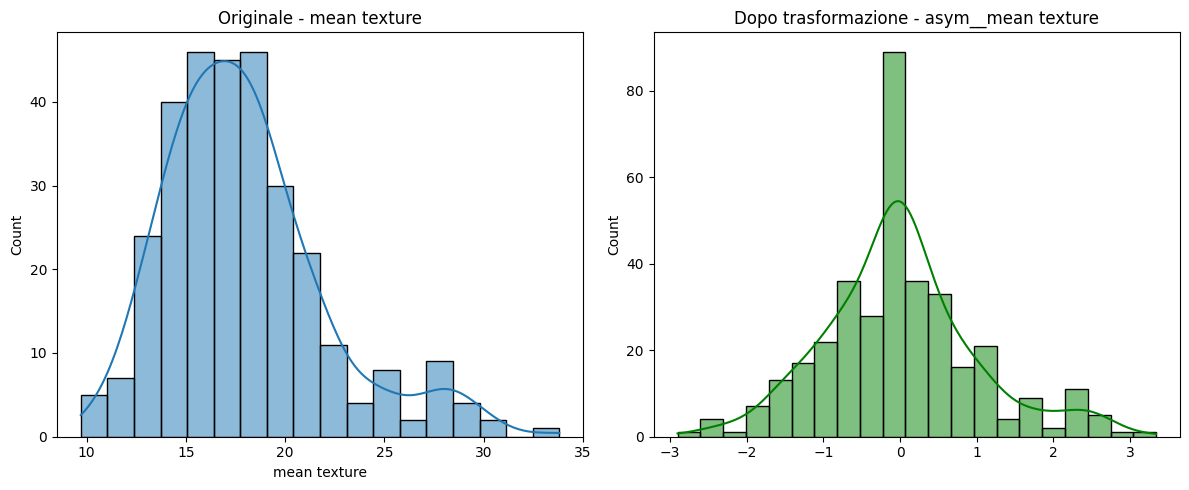

In [ ]:
# Colonna da analizzare (deve essere numerica e asimmetrica)
col = 'mean texture'
# Trova l'indice corretto della colonna trasformata
col_transformed_name = f"asym__{col}"
if col_transformed_name not in feature_names:
    raise ValueError(f"La colonna trasformata '{col_transformed_name}' non è stata trovata.\nColonne disponibili: {feature_names}")

idx = feature_names.index(col_transformed_name)
# Filtra i record con target == 1
mask = df_tumore_seno['target'] == 1
original_values = df_tumore_seno.loc[mask, col].dropna()
transformed_values = X_transformed[mask][:, idx]

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(original_values, kde=True)
plt.title(f"Originale - {col}")

plt.subplot(1, 2, 2)
sns.histplot(transformed_values, kde=True, color='green')
plt.title(f"Dopo trasformazione - {col_transformed_name}")

plt.tight_layout()
plt.show()

Testo anche le variabile categoriche di cui so che l'unica feature è area error

In [ ]:
# Colonna categorica da analizzare
col = 'area error'

# Applica la pipeline solo ai record con target == 1
pipeline_testcat = create_pipeline_target1(X, y)
pipeline_testcat.fit(X, y)
X_transformed = pipeline_testcat.transform(X)

# Ottengo i nomi delle feature trasformate
tcolumn_transformer = pipeline_testcat.pipeline

feature_names = []
for name, transformer, cols in tcolumn_transformer.transformers_:
    if hasattr(transformer, 'get_feature_names_out'):
        try:
            names = transformer.get_feature_names_out(cols)
        except:
            names = cols  # fallback
    else:
        names = cols
    feature_names.extend([f"{name}__{n}" for n in names])

# Filtra i nomi e gli indici delle colonne categoriche trasformate
cat_feature_names = [name for name in feature_names if name.startswith("cat__")]
cat_indices = [i for i, name in enumerate(feature_names) if name.startswith("cat__")]

# Filtra i record con target == 1
mask = df_tumore_seno['target'] == 1
original_cats = df_tumore_seno.loc[mask, col].reset_index(drop=True)
transformed_cats = pd.DataFrame(X_transformed[mask][:, cat_indices], columns=cat_feature_names)

# Unisci valori originali e trasformati
comparison_df = pd.concat([original_cats, transformed_cats], axis=1)
comparison_df.head(10)



Numeriche: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Categoriche: ['area error']
Simmetriche: ['mean radius', 'mean perimeter', 'mean area', 'mean symmetry', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst concave points', 'worst symmetry']
Asimmetriche: ['mean texture', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'smoo

,area error,cat__area error_A
0,A,1.0
1,A,1.0
2,NaN,1.0
3,A,1.0
4,A,1.0
5,A,1.0
6,A,1.0
7,NaN,1.0
8,A,1.0
9,A,1.0


Dato che vedo come valore unico solo A in area error faccio alcuni test

In [ ]:
# verifico i valori unici nell'intero dataset
print("Valori unici in area error:", df_tumore_seno['area error'].value_counts(dropna=False))

Valori unici in area error: area error
A      489
NaN     75
B        4
C        1
Name: count, dtype: int64


In [ ]:
# quindi verifico il numero dei valori e delle colonne trasformate
print("Colonne categoriche trasformate:", cat_feature_names)
print("Shape delle colonne cat:", transformed_cats.shape)

Colonne categoriche trasformate: ['cat__area error_A']
Shape delle colonne cat: (357, 1)


In [ ]:
# Controlla i valori di area error solo per target=1 e vedo che ritorna
target_1_area_error = df_tumore_seno[df_tumore_seno['target'] == 1]['area error'].value_counts(dropna=False)
print("Area error per target=1:", target_1_area_error)

Area error per target=1: area error
A      316
NaN     41
Name: count, dtype: int64


Pipeline 2


Prima di creare il ColumTransformer verifico i valori della variabile categorica dato che devo codificarlo per un ordine crescente, mentre per quello numerico avevo già visto in precedenza tramite analisi esplorativa, dove verificavo se c'erano valori mancanti per poi effettuare il missing

In [ ]:
# estraggo i valori unici per poi impostare l'ordinamento
ordin = df_tumore_seno['area error'].unique()
print(ordin)
# a questo punto dopo chge avrò effettuato il missing posso affermare che la mia lista sarà questa e la salvo su una variabile che poi passerò al mio encoder
ordinal_categories = [['A', 'B', 'C']]

['A' nan 'B' 'C']


Creo degli istogrammi per vedere se le distribuzioni sono uniformi o simmetriche o sbilanciate, vedo che le variabili sono diverse tra loro,alcune con leggera assimetria, alcune fortemente skewed e in precedenza avevo creato una classe per la gestione di questo e quindi è anche un indizio, quindi opterei per la strategia quantile

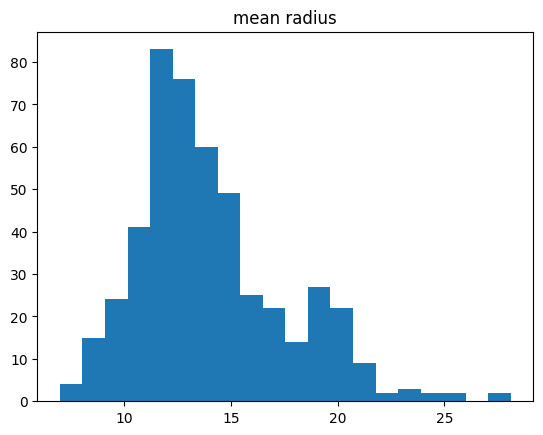

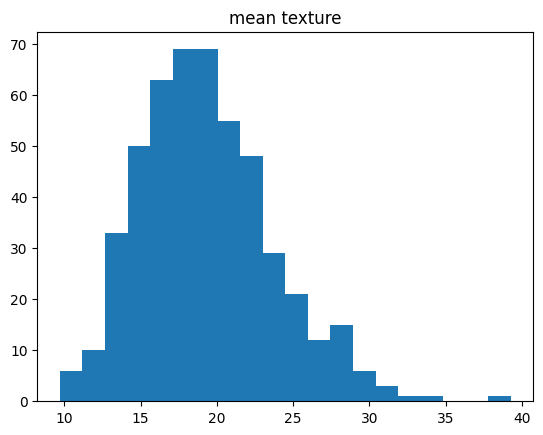

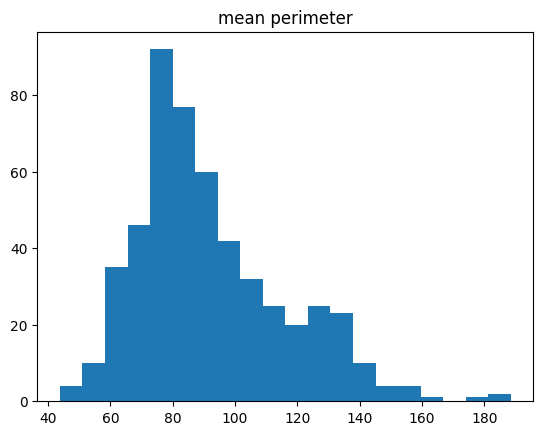

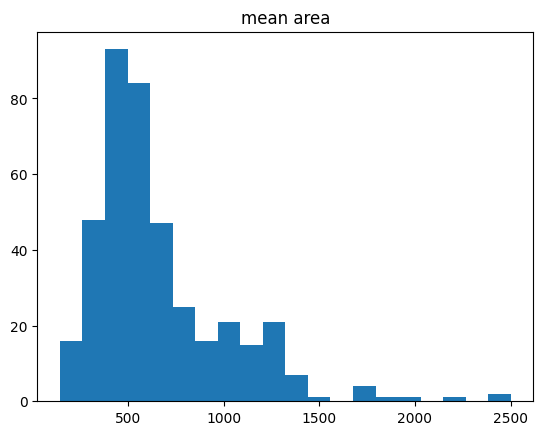

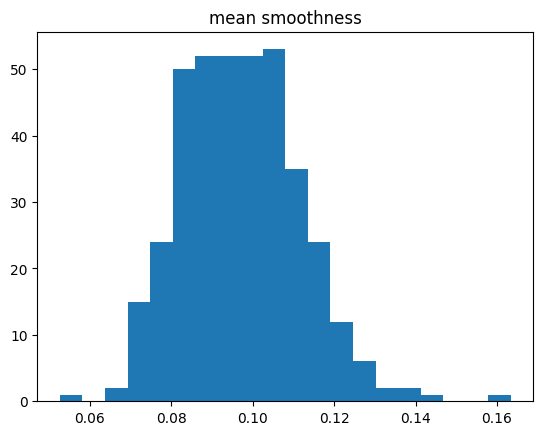

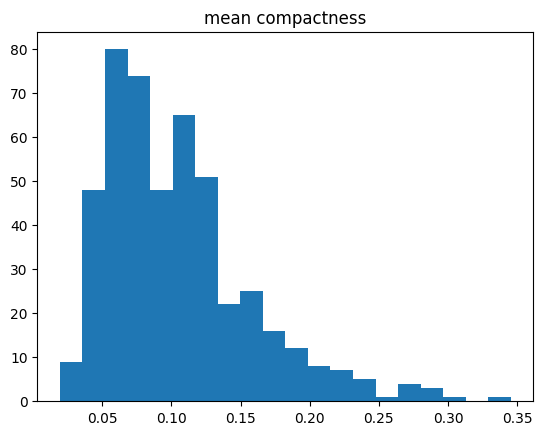

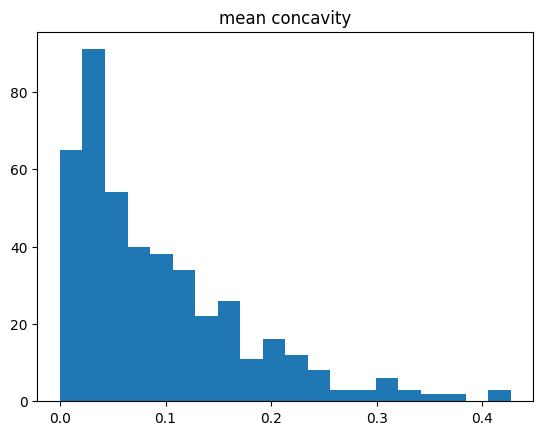

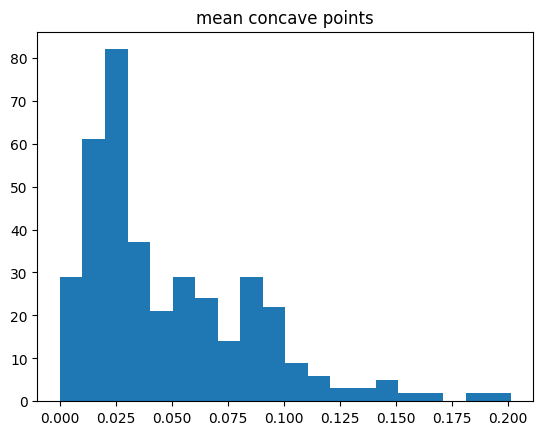

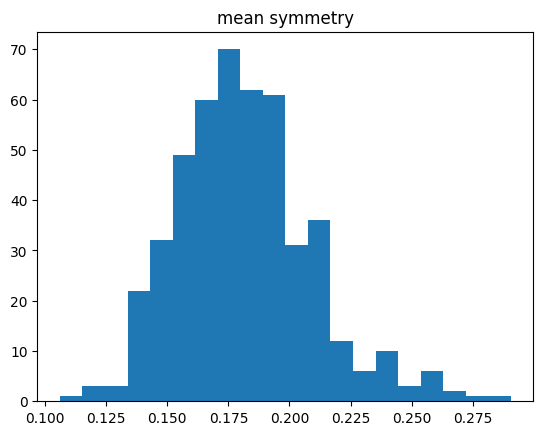

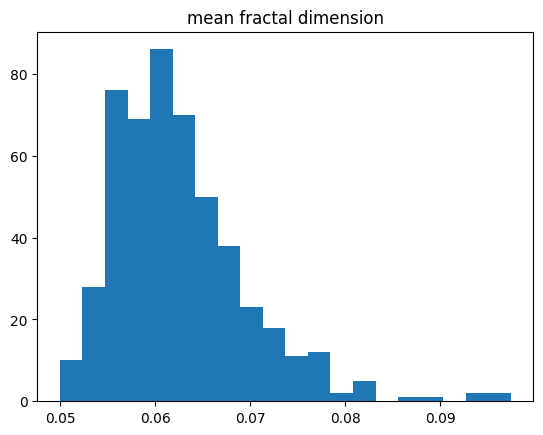

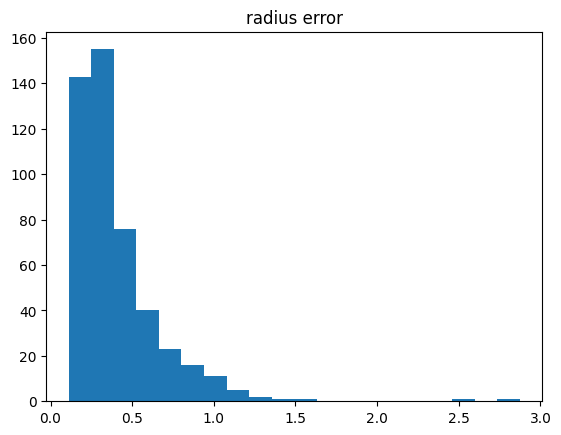

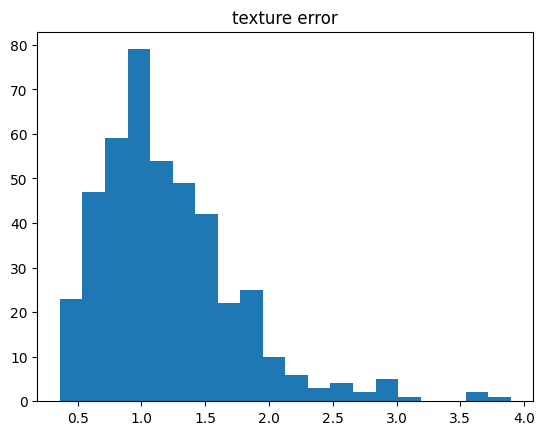

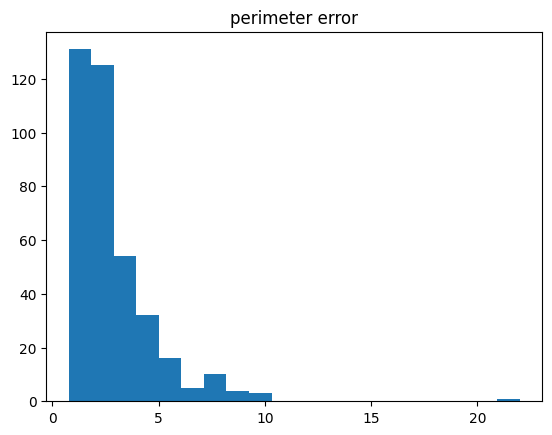

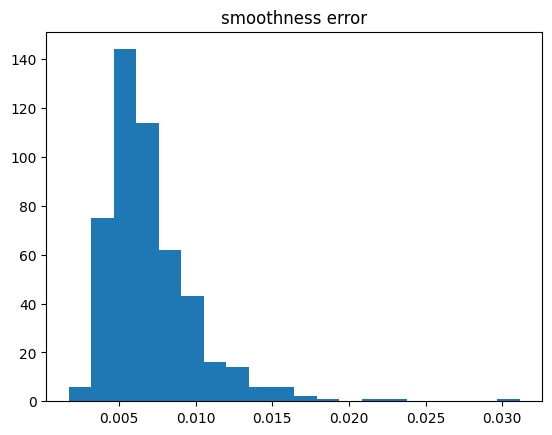

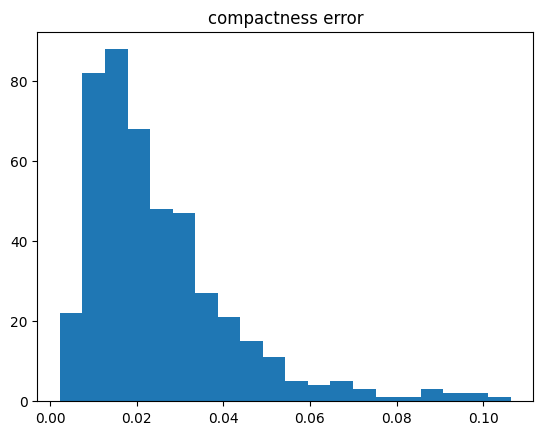

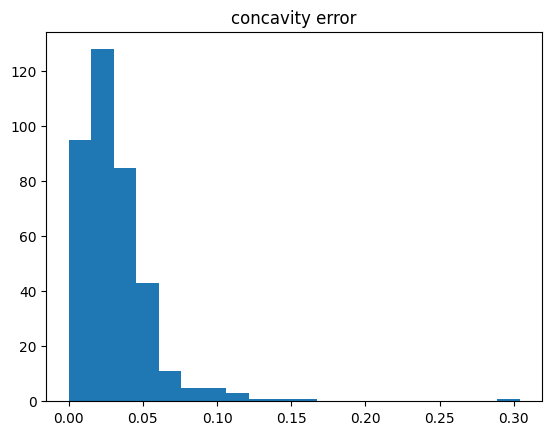

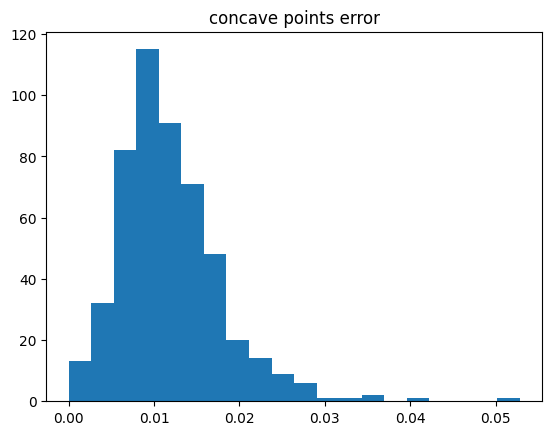

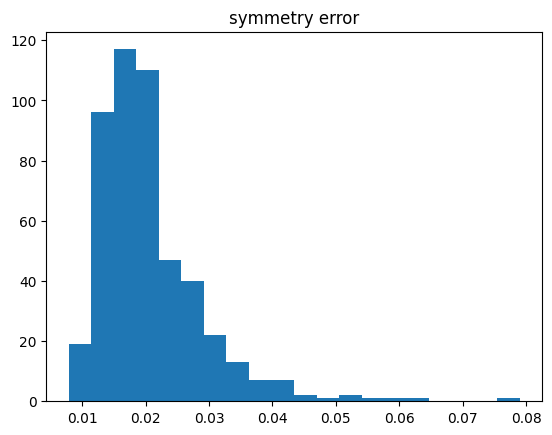

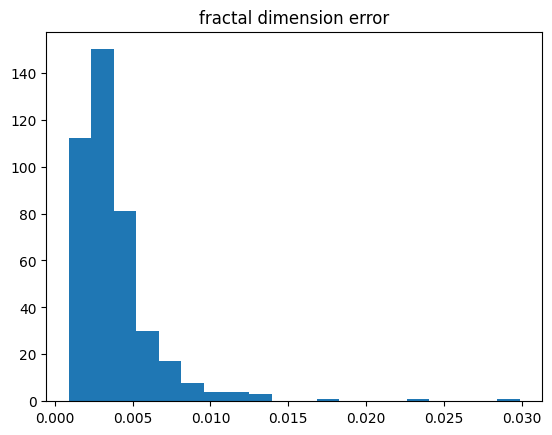

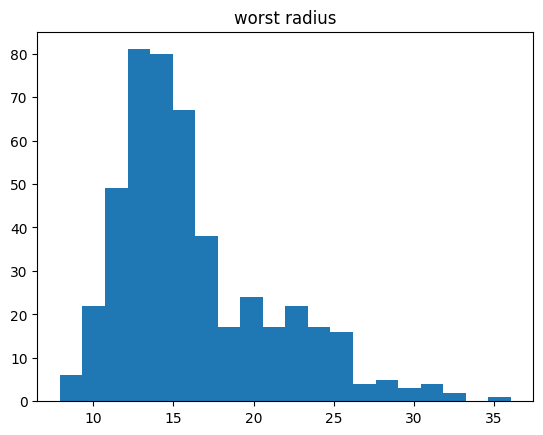

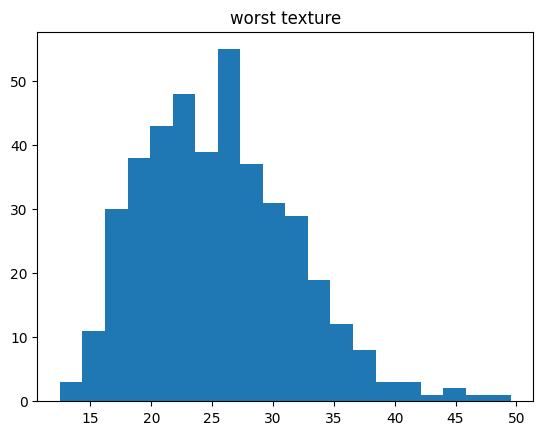

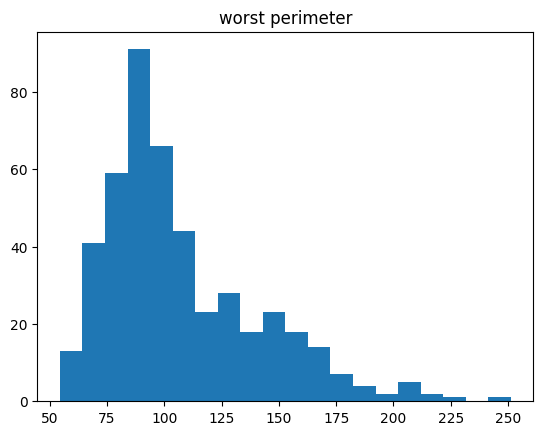

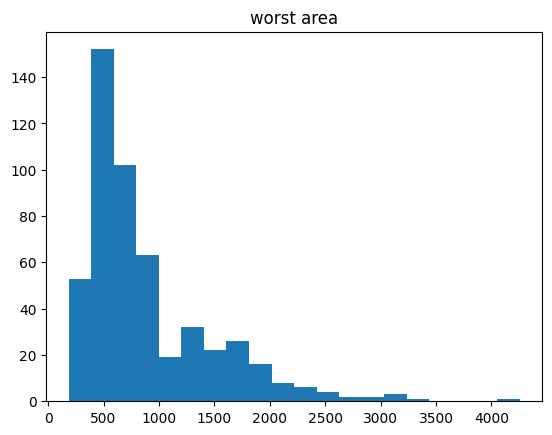

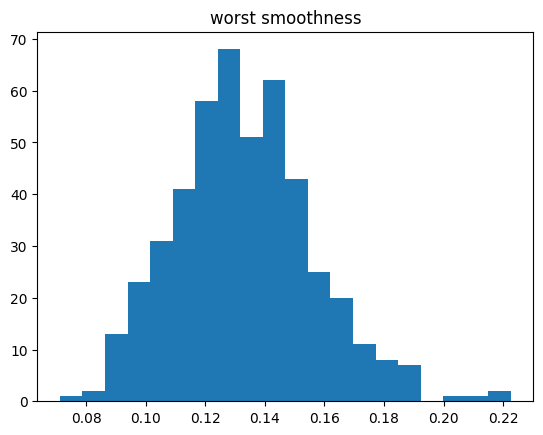

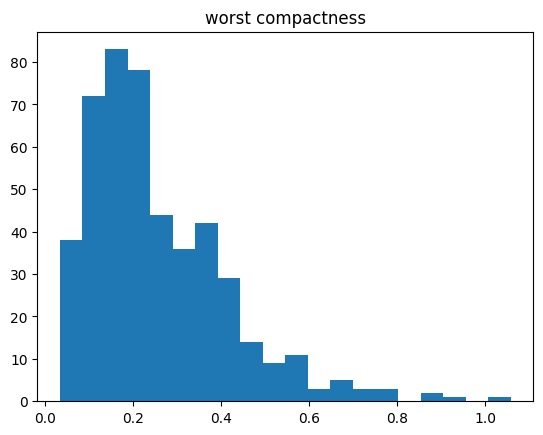

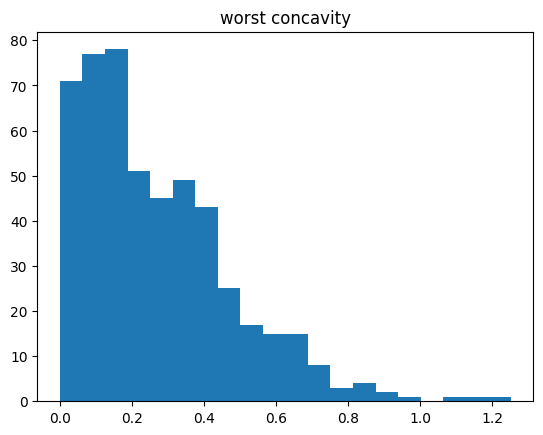

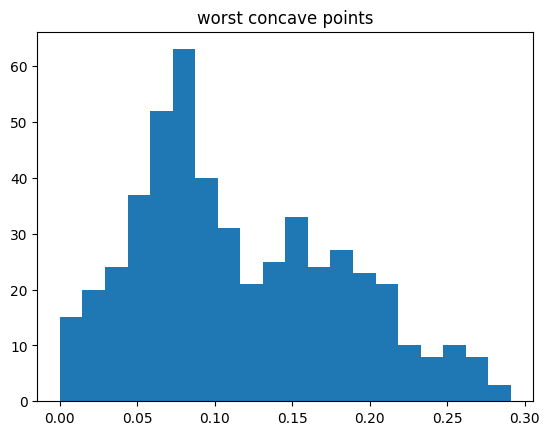

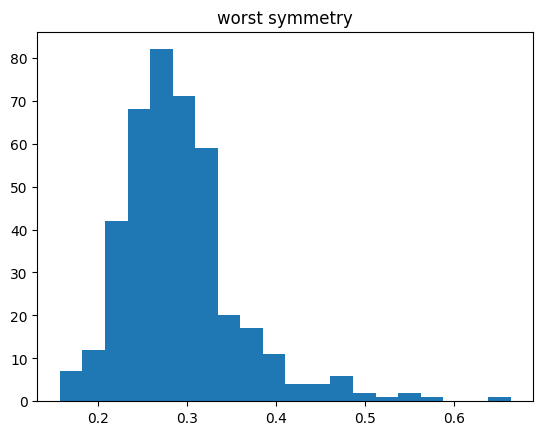

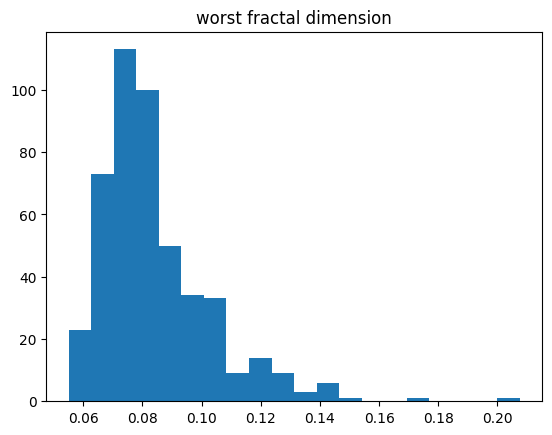

In [ ]:

#testo con 20 bins come richiesto dal progetto
for col in X.select_dtypes(include='number').columns:
    plt.hist(X[col].dropna(), bins=20)
    plt.title(col)
    plt.show()


Creo il ColumnTransformer ma facendo delle prove mi sono accorto che c'erano troppi warning e ho diminuito i bins fin quando non avevo warning


In [ ]:
# creo il ColumnTransformer
ct = ColumnTransformer([
    (   'numeriche',
        Pipeline([
            ('missing', SimpleImputer(strategy='mean')),
            ('discretizer', KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile'))
        ]),
        make_column_selector(dtype_exclude=['object','category','bool'])
        ),


        ('categoriche',
        Pipeline([
            ('missing', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(categories=ordinal_categories))
        ]),
        make_column_selector(dtype_include=['object','category','bool'])
    ),
])

Seleziono le 5 varibili più importanti con il selectorKbest

In [ ]:
feature_selector = SelectKBest(f_classif, k=5)

Testo la pipeline2


In [ ]:
# creo la pipeline di test
pipeline2_test = Pipeline([
    ('preprocessor', ct),
    ('selector', feature_selector)
])

In [ ]:
# Addestro il preprocessor + selettore supervisionato
pipeline2_test.fit(X, y)
# Applica la trasformazione
X_transformed = pipeline2_test.transform(X)


In [ ]:
print("Forma dati trasformati:", X_transformed.shape)
print("Tipo output:", type(X_transformed))


Forma dati trasformati: (569, 5)
Tipo output: <class 'numpy.ndarray'>


In [ ]:
# Recupero la maschera delle feature selezionate
mask = feature_selector.get_support()

# Ottengo i nomi delle feature originali trasformate dal ColumnTransformer
feature_names = ct.get_feature_names_out()

# Stampo le 5 selezionate
selected_features = feature_names[mask]
print("✅ Feature selezionate:", selected_features)


✅ Feature selezionate: ['numeriche__mean perimeter' 'numeriche__worst perimeter'
 'numeriche__worst area' 'numeriche__worst concavity'
 'numeriche__worst concave points']


Pipeline3



In [ ]:
# Creo come per la pipeline2 un columntransformer che contiene la pipeline delle variabili numeriche
ct_pca = ColumnTransformer([
    ('numeriche_pca',
     Pipeline([
    ('missing', SimpleImputer(strategy='mean')),
    ('skewfix', SkewnessCorrector()),
    ('scaler_pre', StandardScaler()),  # Prima di PCA
    ('pca', PCA(n_components=0.80)),
    ('scaler_post', MinMaxScaler())    # Normalizzazione finale
    ]),
     make_column_selector(dtype_exclude=['object', 'category', 'bool'])
    )
])


In [ ]:
# creo la pipeline di test
pipeline3_test = Pipeline([
    ('preprocessor', ct_pca)
])

In [ ]:
pipeline3_test

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeriche_pca',
                                                  Pipeline(steps=[('missing',
                                                                   SimpleImputer()),
                                                                  ('skewfix',
                                                                   SkewnessCorrector()),
                                                                  ('scaler_pre',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=0.8)),
                                                                  ('scaler_post',
                                                                   MinMaxScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78fcec652fd0>)]))])

In [ ]:
# ridichiaro la X perchè voglio i dati pulti per il test
X_two = df_tumore_seno.drop('target', axis=1)

# y non serve perché non ho SelectKBest
pipeline3_test.fit(X_two)

X_transformed2 = pipeline3_test.transform(X_two)


In [ ]:
print("Shape dopo discretizzazione:", X_transformed2.shape)
print("Tipo:", type(X_transformed2))


Shape dopo discretizzazione: (569, 8)
Tipo: <class 'numpy.ndarray'>


In [ ]:
# visualizzo i dati dopo la trasformazione
df_transformed = pd.DataFrame(X_transformed2)
print(df_transformed.head())

          0         1         2         3         4         5         6  \
0  0.828520  0.477690  0.259630  0.117804  0.191807  0.604714  0.273446   
1  0.501615  0.067262  0.424681  0.245776  0.393440  0.543284  0.427092   
2  0.624879  0.222411  0.405281  0.326936  0.415522  0.553173  0.431183   
3  0.792637  1.000000  0.100468  0.563204  0.230120  0.817459  0.365917   
4  0.526553  0.238768  0.553074  0.100674  0.452581  0.438870  0.405282   

          7  
0  0.715366  
1  0.578428  
2  0.710347  
3  0.738834  
4  0.689216  


A questo punto dopo aver testato tutte le pipeline singolarmente, ricreo quelle definitive e le combino con una feature unions e applico il fit e la trasformazione , ottenendo l'oggetto finale che sarà pronto per l'analisi da parte del Data Scientist

In [ ]:
# Pipeline 1: target == 1
pipeline1 = create_pipeline_target1(X, y)

# Pipeline 2: preprocessing di tutto il dataset + SelectKBest
pipeline2 = Pipeline([
    ('preprocessor', ct),
    ('selector', feature_selector)
])

# Pipeline 3: PCA su variabili numeriche
pipeline3 = Pipeline([
    ('preprocessor', ct_pca)
])

Numeriche: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Categoriche: ['area error']
Simmetriche: ['mean radius', 'mean perimeter', 'mean area', 'mean symmetry', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst concave points', 'worst symmetry']
Asimmetriche: ['mean texture', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'smoo

In [ ]:
# Unisco le pipeline la FeatureUnions
final_pipeline = FeatureUnion([
    ('pipeline1', pipeline1),
    ('pipeline2', pipeline2),
    ('pipeline3', pipeline3)
])

In [ ]:
final_pipeline.fit(X, y)
obj_final = final_pipeline.transform(X)

In [ ]:
print("Shape finale:", obj_final.shape)
print("Tipo:", type(obj_final))


Shape finale: (569, 43)
Tipo: <class 'numpy.ndarray'>


Faccio i Test dull'oggetto finale

In [ ]:
print(f"Shape del dataset finale: {obj_final.shape}")
print(f"Tipo: {type(obj_final)}")

# Verifico le dimensioni di ogni pipeline
print(f"\nBreakdown delle feature:")
print(f"  Pipeline 1: {pipeline1.transform(X).shape[1]} feature")
#dai test precedenti delle pipeline conoscevo già il numero delle feature, quindi per riassumere il tutto ho stampato.
print(f"  Pipeline 2: 5 feature (SelectKBest)")
print(f"  Pipeline 3: 8 feature (PCA)")
print(f"  TOTALE: {pipeline1.transform(X).shape[1] + 5 + 8} feature")


# Converto obj_final in DataFrame
df_final_view = pd.DataFrame(obj_final)

# Visualizzo le prime 20 righe, prime 15 colonne
df_final_view.iloc[:20, :15]



Shape del dataset finale: (569, 43)
Tipo: <class 'numpy.ndarray'>

Breakdown delle feature:
  Pipeline 1: 30 feature
  Pipeline 2: 5 feature (SelectKBest)
  Pipeline 3: 8 feature (PCA)
  TOTALE: 43 feature


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000


Quindi da qui mi accorgo che probabilmente le prime 19 hanno tutte target = 0 e la 19 =1

In [ ]:
# Verifica che il pattern corrisponda al target
print("Target delle prime 20 righe:")
print(y[:20])

Target delle prime 20 righe:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    1
Name: target, dtype: int64
